<a href="https://colab.research.google.com/github/ayelefeleke/ASTU_LIifestyle_and-Academic-_success/blob/main/ASTU_Lifestyle_And_Success.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df = pd.read_csv("astu_dataset_50_students.csv")

df.head()

,Name,Age,Gender,Study_Hours,Sleep_Hours,Internet_Usage,Attendance(%),Year,Stress_level,GPA,Department
0,Ayele Feleke,21,Male,8,8,3,100,2nd,High,3.96,Software Engineering
1,Fenet Gosa,24,Female,7,8,3,90,3rd,Medium,3.45,Applied Maths
2,Rabira Hundessa,25,Male,4,5,7,70,3rd,High,2.80,Mechanical Engineering
3,Genet Fiqadu,21,Female,8,9,4,89,2nd,Low,3.85,Civil Engineering
4,Sengi Galana,23,Male,3,5,7,65,2nd,High,2.60,Material Engineering


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0        Name               50 non-null     object 
 1                    Age    50 non-null     int64  
 2                   Gender  50 non-null     object 
 3   Study_Hours             50 non-null     int64  
 4   Sleep_Hours             50 non-null     int64  
 5   Internet_Usage          50 non-null     int64  
 6   Attendance(%)           50 non-null     int64  
 7            Year           50 non-null     object 
 8   Stress_level            50 non-null     object 
 9   GPA                     50 non-null     float64
 10  Department              50 non-null     object 
dtypes: float64(1), int64(5), object(5)
memory usage: 4.4+ KB


In [9]:
df.describe()

,Age,Study_Hours,Sleep_Hours,Internet_Usage,Attendance(%),GPA
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,21.620000,5.880000,7.020000,4.520000,84.960000,3.430000
std,1.368598,1.858681,1.463711,1.820966,10.701821,0.455949
min,19.000000,3.000000,5.000000,2.000000,65.000000,2.500000
25%,20.250000,4.000000,6.000000,3.000000,77.250000,3.000000
50%,21.500000,6.000000,7.000000,4.000000,87.000000,3.580000
75%,23.000000,7.000000,8.000000,6.000000,94.500000,3.837500
max,25.000000,9.000000,9.000000,7.000000,100.000000,4.000000


Let check if there
 missing values
 duplicate rows
 consistency of dataset

In [10]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Study_Hours,0
Sleep_Hours,0
Internet_Usage,0
Attendance(%),0
Year,0
Stress_level,0
GPA,0


In [11]:
#df.isnull().sum()
df.fillna(df.mean(numeric_only=True), inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)#

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0        Name               50 non-null     object 
 1                    Age    50 non-null     int64  
 2                   Gender  50 non-null     object 
 3   Study_Hours             50 non-null     int64  
 4   Sleep_Hours             50 non-null     int64  
 5   Internet_Usage          50 non-null     int64  
 6   Attendance(%)           50 non-null     int64  
 7            Year           50 non-null     object 
 8   Stress_level            50 non-null     object 
 9   GPA                     50 non-null     float64
 10  Department              50 non-null     object 
dtypes: float64(1), int64(5), object(5)
memory usage: 4.4+ KB


In [12]:
print("Mean GPA:", df["GPA"].mean())
print("Median GPA:", df["GPA"].median())
print("Std GPA:", df["GPA"].std())

Mean GPA: 3.43
Median GPA: 3.58
Std GPA: 0.4559493348151386


In [13]:
df["Lifestyle_Score"] = (
    df["Sleep_Hours"]*0.3 +
    df["Study_Hours"]*0.3 +
    df["Attendance(%)"]*0.3 -
    df["Internet_Usage"]*0.1
)

This is lifescore result for each student to see where they are compared to the other based on this data.

In [14]:
print(df["Lifestyle_Score"])


0     34.5
1     31.2
2     23.0
3     31.4
4     21.2
5     31.1
6     31.4
7     27.7
8     23.3
9     28.7
10    33.6
11    32.4
12    30.0
13    23.7
14    32.0
15    30.8
16    32.0
17    28.8
18    27.9
19    29.8
20    30.5
21    31.0
22    28.9
23    33.0
24    25.5
25    27.9
26    32.1
27    28.3
28    21.6
29    26.6
30    25.5
31    28.2
32    28.7
33    34.0
34    22.4
35    34.1
36    23.3
37    32.2
38    25.4
39    30.8
40    29.7
41    23.4
42    29.3
43    28.8
44    32.0
45    34.2
46    27.2
47    30.0
48    28.8
49    27.4
Name: Lifestyle_Score, dtype: float64


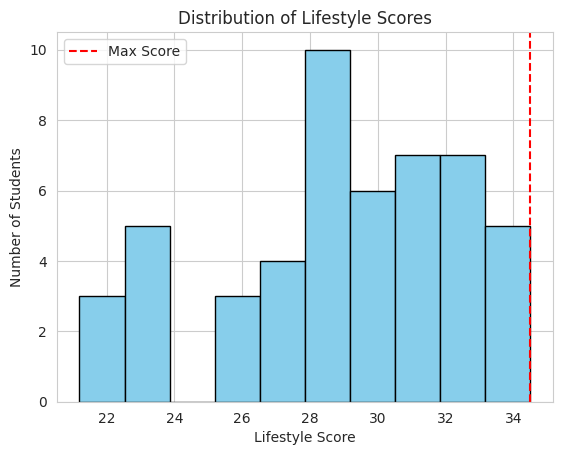

In [15]:

plt.hist(df["Lifestyle_Score"], bins=10, color="skyblue", edgecolor="black")
plt.title("Distribution of Lifestyle Scores")
plt.xlabel("Lifestyle Score")
plt.ylabel("Number of Students")
plt.axvline(df["Lifestyle_Score"].max(), color="red", linestyle="--", label="Max Score")
plt.legend()
plt.show()


Correlation values range from -1 to +1.
-> Toward +1 means as one increases, the other increases.
-> -1 means as one increases, the other decreases.
-> 0 means no linear relationship.


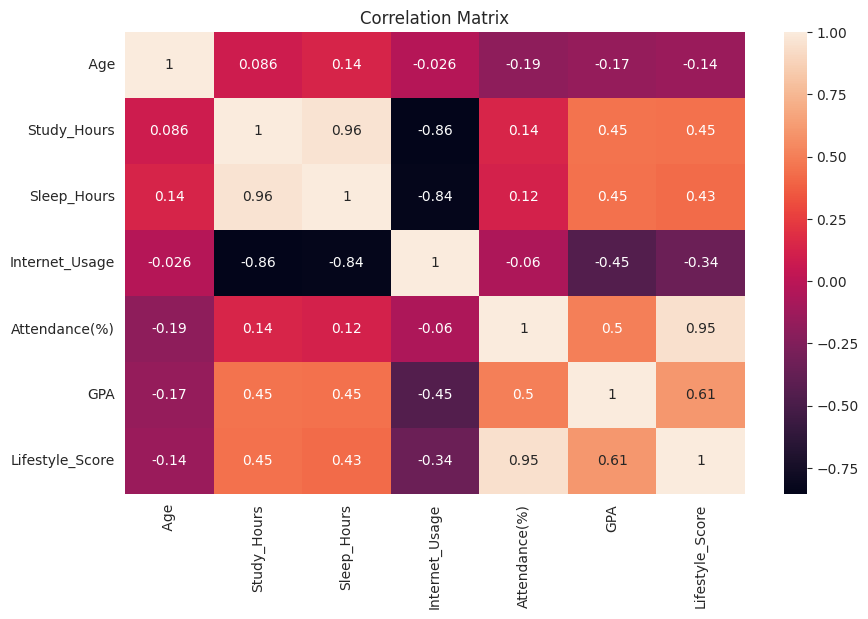

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [16]:
df["Stress_level_Num"] = df["Stress_level"].map({
    "Low":1,
    "Medium":2,
    "High":3
})
df[["Stress_level","Stress_level_Num"]].head()

,Stress_level,Stress_level_Num
0,High,3
1,Medium,2
2,High,3
3,Low,1
4,High,3


This is lifestyle of some students where they are based on Study_Hours

In [17]:
df["Lifestyle_Group"]=pd.cut(df["Study_Hours"],bins=[0,3,6,10],
 labels=["Low","Moderate","High"]
                         )
df.head()

,Name,Age,Gender,Study_Hours,Sleep_Hours,Internet_Usage,Attendance(%),Year,Stress_level,GPA,Department,Lifestyle_Score,Stress_level_Num,Lifestyle_Group
0,Ayele Feleke,21,Male,8,8,3,100,2nd,High,3.96,Software Engineering,34.5,3,High
1,Fenet Gosa,24,Female,7,8,3,90,3rd,Medium,3.45,Applied Maths,31.2,2,High
2,Rabira Hundessa,25,Male,4,5,7,70,3rd,High,2.80,Mechanical Engineering,23.0,3,Moderate
3,Genet Fiqadu,21,Female,8,9,4,89,2nd,Low,3.85,Civil Engineering,31.4,1,High
4,Sengi Galana,23,Male,3,5,7,65,2nd,High,2.60,Material Engineering,21.2,3,Low


In [18]:
df.groupby("Department")["GPA"].mean().sort_values(ascending=False)

,GPA
Department,
Software Engineering,3.8800
Computer Science,3.8625
Applied pysics,3.7800
Applied Maths,3.7500
Architecture,3.7400
Pharmacy,3.6000
Applied Maths,3.3400
Mechanical Engineering,3.3130
Civil Engineering,3.2800


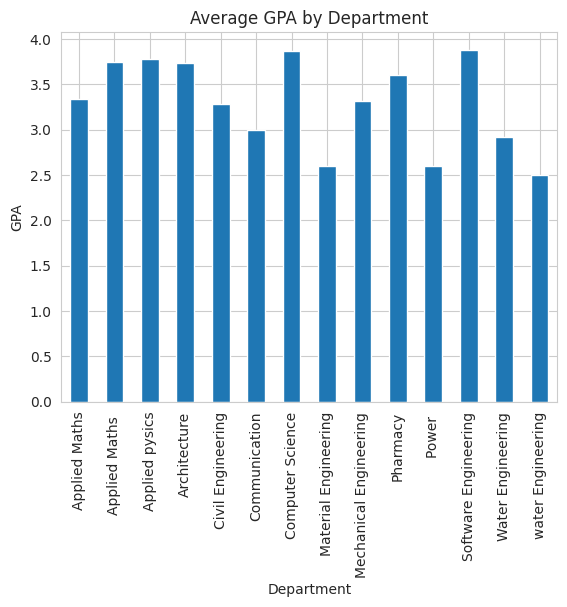

In [ ]:
df.groupby("Department")["GPA"].mean().plot(kind="bar")
plt.title("Average GPA by Department")
plt.ylabel("GPA")
plt.show()

 GPA Percentile Ranking

In [ ]:
df["GPA_Percentile"] = df["GPA"].rank(pct=True)
df.sort_values("GPA_Percentile", ascending=False).head()

,Name,Age,Gender,Study_Hours,Sleep_Hours,Internet_Usage,Attendance(%),Year,Stress_level,GPA,Department,Lifestyle_Score,Stress_level_Num,Lifestyle_Group,GPA_Percentile
10,Kalkidan Tesema,22,Female,6,7,3,100,3rd,Medium,4.00,Computer Science,33.6,2,Moderate,1.00
30,Yerosan Badhasa,21,Male,5,6,3,75,2nd,High,3.97,Computer Science,25.5,3,Moderate,0.98
35,Ameyu Waquma,22,Female,7,8,4,100,2nd,Medium,3.96,Computer Science,34.1,2,High,0.95
0,Ayele Feleke,21,Male,8,8,3,100,2nd,High,3.96,Software Engineering,34.5,3,High,0.95
23,Melat Yoseph,23,Female,9,9,3,93,3rd,Low,3.95,Software Engineering,33.0,1,High,0.92


In [19]:
df.columns = df.columns.str.strip()

In [20]:
df.groupby(["Gender","Lifestyle_Group","Year"])["GPA"].mean()

/tmp/ipykernel_3599/3088926224.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Gender","Lifestyle_Group","Year"])["GPA"].mean()


Gender  Lifestyle_Group  Year
Female  Low              2nd          NaN
                         3rd          NaN
        Moderate         2nd     3.158000
                         3rd     4.000000
        High             2nd     3.660769
                         3rd     3.533750
Male    Low              2nd     2.994000
                         3rd     3.245000
        Moderate         2nd     3.477500
                         3rd     2.900000
        High             2nd     3.960000
                         3rd          NaN
Name: GPA, dtype: float64

In [21]:
numeric_cols = [
    "Age",
    "Study_Hours",
    "Sleep_Hours",
    "Internet_Usage",
    "Attendance(%)",
    "Stress_level",
    "GPA"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

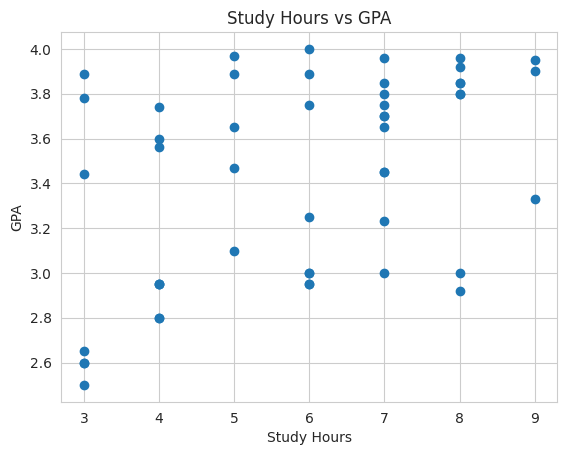

In [22]:
plt.scatter(df["Study_Hours"], df["GPA"])
plt.title("Study Hours vs GPA")
plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.show()

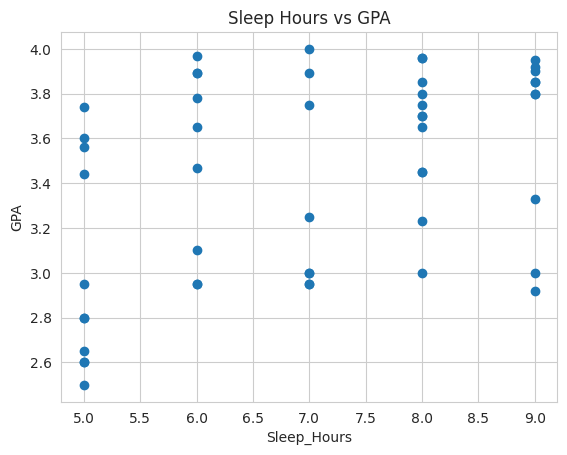

In [ ]:
plt.scatter(df["Sleep_Hours"], df["GPA"])
plt.title("Sleep Hours vs GPA")
plt.xlabel("Sleep_Hours")
plt.ylabel("GPA")
plt.show()

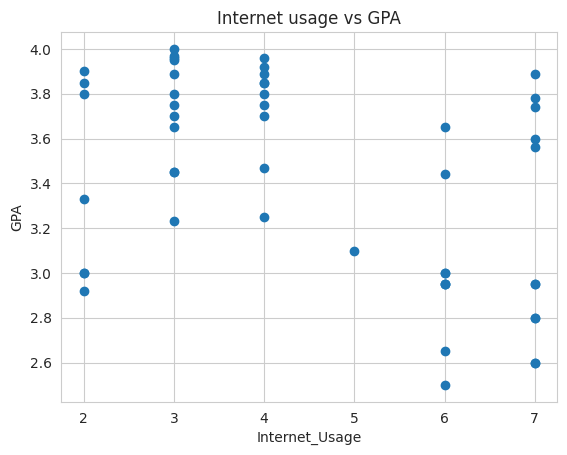

In [ ]:
plt.scatter(df["Internet_Usage"], df["GPA"])
plt.title("Internet usage vs GPA")
plt.xlabel("Internet_Usage")
plt.ylabel("GPA")
plt.show()

Stress Efficiency is the ratio of GPA and Stress level num

In [ ]:
df["Stress_Efficiency"] = df["GPA"]/df["Stress_level_Num"]
print(df["Stress_Efficiency"])

0     1.320000
1     1.725000
2     0.933333
3     3.850000
4     0.866667
5     1.925000
6     1.296667
7     3.330000
8     0.983333
9     1.296667
10    2.000000
11    0.983333
12    3.700000
13    1.615000
14    1.200000
15    3.920000
16    1.625000
17    1.000000
18    0.883333
19    2.920000
20    1.186667
21    1.500000
22    1.033333
23    3.950000
24    0.833333
25    1.875000
26    1.216667
27    3.800000
28    0.983333
29    1.900000
30    1.323333
31    1.725000
32    0.933333
33    3.850000
34    0.866667
35    1.980000
36    1.156667
37    3.900000
38    0.983333
39    1.260000
40    1.945000
41    0.983333
42    3.700000
43    1.825000
44    1.246667
45    3.800000
46    1.875000
47    1.000000
48    1.146667
49    3.000000
Name: Stress_Efficiency, dtype: float64


In [ ]:


pd.crosstab(df["Gender"], df["Lifestyle_Group"])

Lifestyle_Group,Low,Moderate,High
Gender,,,
Female,0,6,21
Male,7,15,1


In [ ]:
pd.crosstab(df["Gender"], df["Lifestyle_Group"], normalize="index") * 100

Lifestyle_Group,Low,Moderate,High
Gender,,,
Female,0.000000,22.222222,77.777778
Male,30.434783,65.217391,4.347826


correlation GPA vs Study Hours vs Sleep

In [ ]:
df[["GPA", "Study_Hours", "Sleep_Hours"]].corr()

,GPA,Study_Hours,Sleep_Hours
GPA,1.000000,0.450323,0.445851
Study_Hours,0.450323,1.000000,0.961083
Sleep_Hours,0.445851,0.961083,1.000000


let visualize it

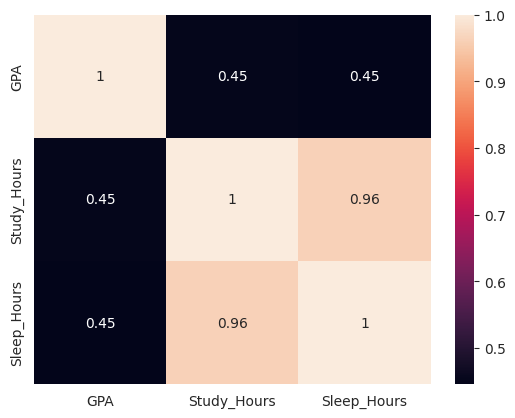

In [ ]:


sns.heatmap(df[["GPA","Study_Hours","Sleep_Hours"]].corr(), annot=True)
plt.show()


GPA distribution by

In [ ]:
df["GPA"].quantile([0.25, 0.5, 0.75])

,GPA
0.25,3.0000
0.50,3.5800
0.75,3.8375


In [ ]:
cohort = df.groupby(["Gender", "Lifestyle_Group"])["GPA"].mean().reset_index()
cohort

/tmp/ipykernel_6983/3251627231.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort = df.groupby(["Gender", "Lifestyle_Group"])["GPA"].mean().reset_index()


,Gender,Lifestyle_Group,GPA
0,Female,Low,NaN
1,Female,Moderate,3.298333
2,Female,High,3.612381
3,Male,Low,3.065714
4,Male,Moderate,3.362000
5,Male,High,3.960000
